In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

original_df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
encoded_data = pd.read_csv("../data/proccessed/finish-unsupervised.csv")
encoded_data['Churn'] = original_df['Churn'].map({'Yes': 1, 'No': 0})
encoded_data.to_csv('../data/proccessed/telco_prepared_for_supervised.csv', index=False)


Random Forest Accuracy (Threshold 0.24): 0.7268

Random Forest Classification Report (Threshold 0.24):
              precision    recall  f1-score   support

No Churn (0)       0.92      0.68      0.79      1035
   Churn (1)       0.49      0.84      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.73      0.74      1409



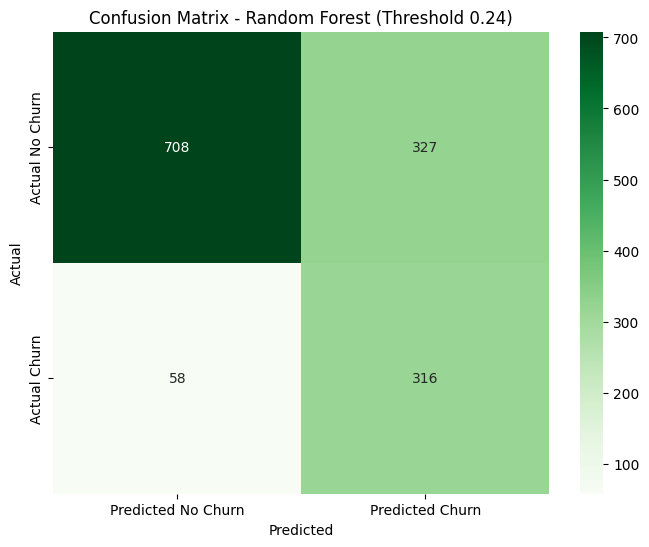

Random Forest ROC-AUC Score: 0.8436



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    roc_auc_score,
    roc_curve
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/proccessed/telco_prepared_for_supervised.csv')

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

X = df.drop("Churn" , axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(random_state=42 , n_estimators=300, max_depth=7 , min_samples_leaf=10 , min_samples_split=10)
rf_model.fit(X_train_scaled, y_train)

y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]


threshold = 0.24
y_pred_custom_rf = (y_pred_proba_rf >= threshold).astype(int)


accuracy_rf = accuracy_score(y_test, y_pred_custom_rf)
print(f"Random Forest Accuracy (Threshold {threshold}): {accuracy_rf:.4f}\n")

print(f"Random Forest Classification Report (Threshold {threshold}):")
print(classification_report(y_test, y_pred_custom_rf, target_names=['No Churn (0)', 'Churn (1)']))

cm_rf = confusion_matrix(y_test, y_pred_custom_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted No Churn', 'Predicted Churn'], 
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title(f'Confusion Matrix - Random Forest (Threshold {threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest ROC-AUC Score: {auc_rf:.4f}\n")





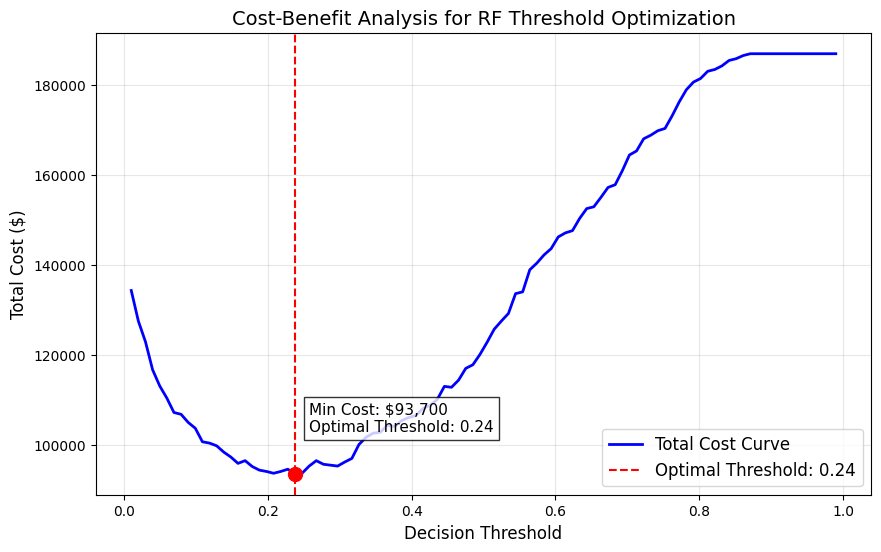

✅ Random Forest: 0.24
✅: $93,700


In [ ]:
import numpy as np
def optimize_threshold_by_cost(y_true, y_probs, cost_FP=100, cost_FN=500, cost_TP=100, cost_TN=0):

    thresholds = np.linspace(0.01, 0.99, 100)
    costs = []

    for thresh in thresholds:

        y_pred = (y_probs >= thresh).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        

        total_cost = (fp * cost_FP) + (fn * cost_FN) + (tp * cost_TP) + (tn * cost_TN)
        costs.append(total_cost)


    min_cost = min(costs)
    optimal_threshold = thresholds[costs.index(min_cost)]


    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, costs, linewidth=2, color='blue', label='Total Cost Curve')

    plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal Threshold: {optimal_threshold:.2f}')
    plt.scatter(optimal_threshold, min_cost, color='red', s=100, zorder=5)
    

    plt.title('Cost-Benefit Analysis for RF Threshold Optimization', fontsize=14)
    plt.xlabel('Decision Threshold', fontsize=12)
    plt.ylabel('Total Cost ($)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    
   
    plt.text(optimal_threshold + 0.02, min_cost + (max(costs)*0.05), 
             f'Min Cost: ${min_cost:,.0f}\nOptimal Threshold: {optimal_threshold:.2f}', 
             fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.show()
    
    print(f"✅ Random Forest: {optimal_threshold:.2f}")
    print(f"✅: ${min_cost:,.0f}")
    
    return optimal_threshold

optimal_thresh_rf = optimize_threshold_by_cost(y_test, y_pred_proba_rf)



In [29]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced', 
        'random_state': 42
    }
    
    model = RandomForestClassifier(**params)

    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    return score

print("Starting Optuna optimization for Random Forest...")
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=200) 

print(f"\nBest RF Params: {study_rf.best_params}")
print(f"Best RF ROC-AUC: {study_rf.best_value:.4f}\n")


[I 2026-05-19 08:06:22,354] A new study created in memory with name: no-name-7777fa27-a185-4622-b21c-1bc969e8d5e9


Starting Optuna optimization for Random Forest...


[I 2026-05-19 08:06:25,078] Trial 0 finished with value: 0.8446044848511918 and parameters: {'n_estimators': 200, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8446044848511918.
[I 2026-05-19 08:06:27,978] Trial 1 finished with value: 0.8441420468577524 and parameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8446044848511918.
[I 2026-05-19 08:06:33,557] Trial 2 finished with value: 0.8441428888929134 and parameters: {'n_estimators': 400, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8446044848511918.
[I 2026-05-19 08:06:35,385] Trial 3 finished with value: 0.8359560540481856 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8446044848511918.
[I 2026-05-19 08:06:43,019] Trial 4 finished with value: 0.8439344036244945 and parameters: {'n


Best RF Params: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 10}
Best RF ROC-AUC: 0.8447



/var/folders/33/1_9c8vl1123ffv0k7k3c_44c0000gn/T/ipykernel_24411/867972995.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_imp_df.head(10), palette='mako')


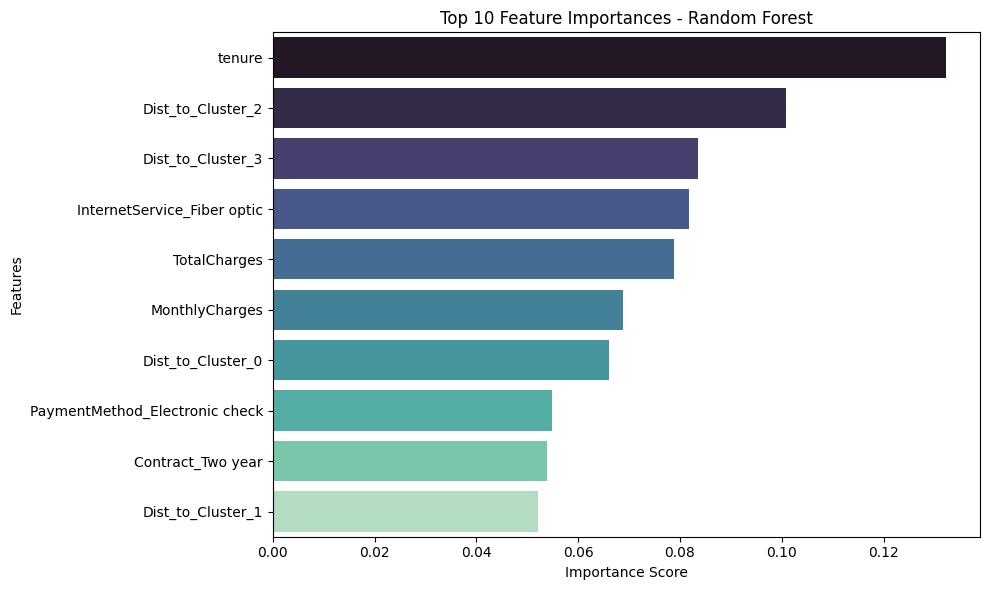

Top 10 Important Features (Random Forest):
                           Feature  Importance
4                           tenure    0.132343
34               Dist_to_Cluster_2    0.100748
35               Dist_to_Cluster_3    0.083464
11     InternetService_Fiber optic    0.081869
8                     TotalCharges    0.078822
7                   MonthlyCharges    0.068822
32               Dist_to_Cluster_0    0.066042
28  PaymentMethod_Electronic check    0.054868
26               Contract_Two year    0.053871
33               Dist_to_Cluster_1    0.052209


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


rf_importances = rf_model.feature_importances_


rf_feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_imp_df.head(10), palette='mako')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


print("Top 10 Important Features (Random Forest):")
print(rf_feature_imp_df.head(10))


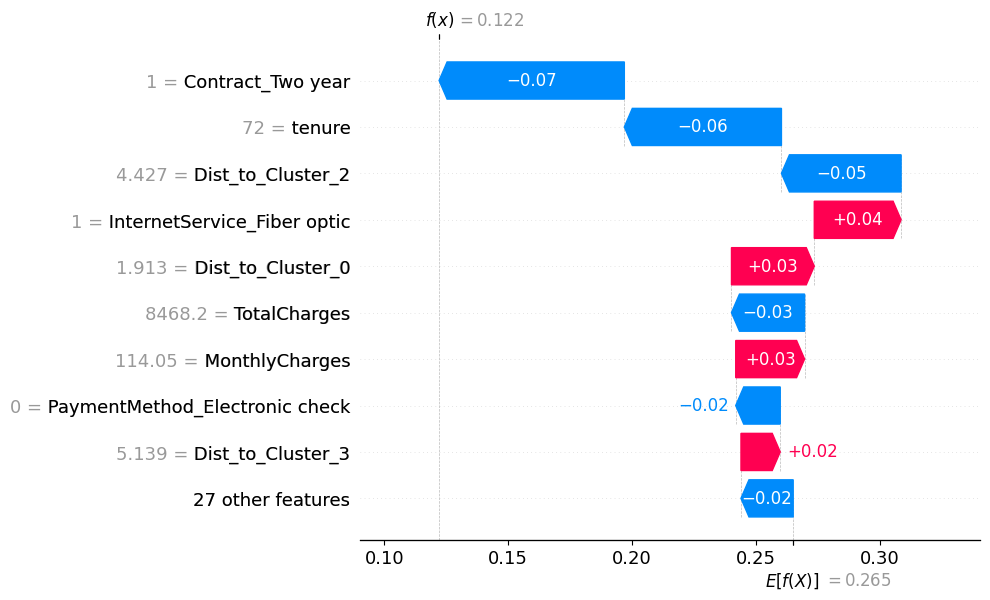

In [6]:
import shap

# ساخت Explainer
rf_explainer = shap.TreeExplainer(rf_model)

# محاسبه مقادیر SHAP به صورت آبجکت Explanation (روش جدید)
# این مرحله ممکن است کمی زمان ببرد
rf_shap_values_obj = rf_explainer(X_test)

# رسم نمودار آبشاری برای مشتری اول (ایندکس 0) و کلاس 1 (ریزش)
# در مدل‌های چندکلاسه‌ی scikit-learn بُعد سوم نشان‌دهنده کلاس است
shap.plots.waterfall(rf_shap_values_obj[0, :, 1])


/Users/mohammad/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


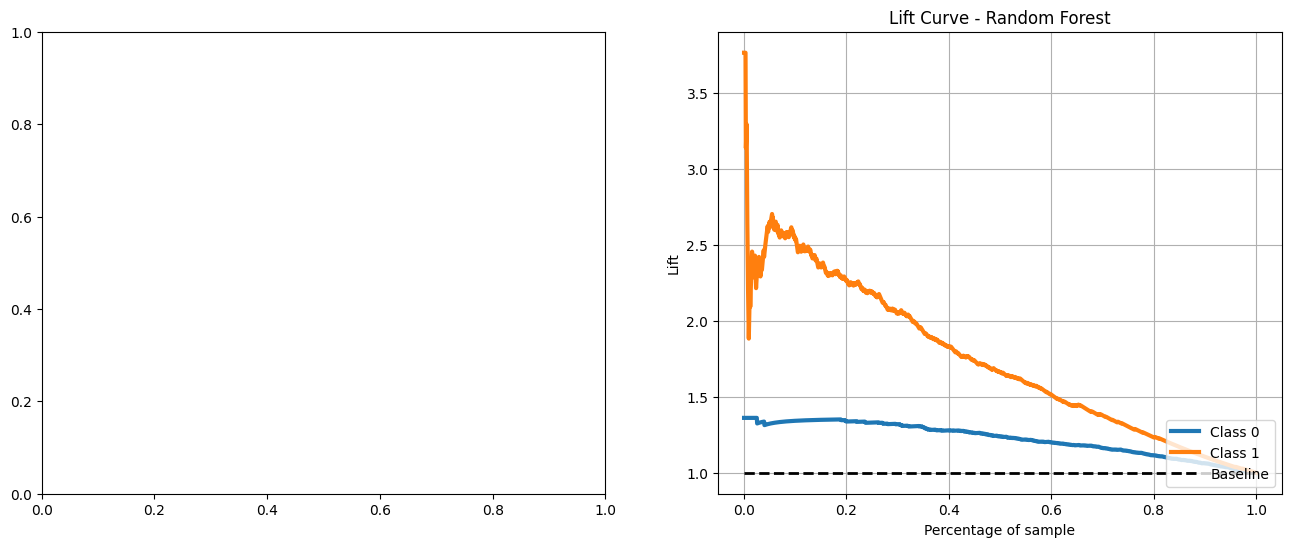

In [ ]:
import numpy as np
import scipy

scipy.interp = np.interp 
import scikitplot as skplt
import matplotlib.pyplot as plt
probas_rf = rf_model.predict_proba(X_test)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
skplt.metrics.plot_lift_curve(y_test, probas_rf, ax=ax[1], title="Lift Curve - Random Forest")
plt.show()
